# 10 · SSVEP: spectral peaks and canonical correlation

**ROBT613 · Brain–Computer Interfaces** | Teaching session + independent lab

## Goal
Decode 12 versus 15 Hz visual stimulation using spectral signal-to-noise ratio and a sinusoidal-reference CCA decoder.

**Data:** Native MNE SSVEP dataset, participant 02

Run cells from top to bottom in a fresh CPU runtime. No previous notebook state is required.

## How to study this notebook

This is both the classroom lesson and the independent-study workbook. Everything needed for the exercises—questions, hints, executable solutions, checks and explanations—is here. Work from top to bottom in a fresh runtime.

1. Read the question and calculate a small example on paper.
2. Write your prediction before running the next code cell.
3. Try the practice task in its workspace.
4. Continue to the worked solution and compare the reasoning, not just the number.
5. Change one parameter and explain what the result means.

**For a live class:** pause at each “Try it” heading. The solution follows in the same notebook, so no separate answer document is required. Saved figures support reading without execution; downloading real data and rerunning cells requires internet on the first run. Code comments explain each analysis statement, and longer loops are explained before execution.

**Prerequisites:** basic Python arrays, arithmetic and plotting. The symbol guide below defines the mathematical notation used here. These lessons stay at the sensor level; EEG source imaging is outside the course.

## The question for today

A participant attends to one of two flickering targets. Can a few seconds of occipital EEG identify the attended frequency? We compare spectral evidence with a multichannel correlation method and examine the assumptions behind a fast decision.

### By the end you should be able to

- Relate observation duration to frequency discrimination.
- Build sine/cosine reference matrices with harmonics.
- Explain canonical correlation as a comparison of two multivariate signals.
- Distinguish benchmark trial classification from a usable asynchronous interface.

**How to work:** predict each result before running it, execute one cell at a time, and write a short interpretation. The first worked examples use controlled arrays; the later walkthrough and applied practice use the dataset stated above. Practice workspaces, hints and worked solutions are placed beside the relevant methods. Complete your attempt before continuing to the reference solution.

## Setup
The first cell installs the tested core versions in Colab. Downloads are cached in `mne_data/`; a new Colab runtime loses that cache. A failed download is an error, never silently replaced by synthetic data.

In [1]:
# Colab: install before importing numerical libraries. Restart if pip requests it.
import sys, subprocess, os
if 'google.colab' in sys.modules:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q',
                           'mne==1.13.2', 'moabb==1.7.2'])
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mne
from scipy import signal
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (balanced_accuracy_score, roc_auc_score,
                             ConfusionMatrixDisplay, classification_report)
from sklearn.model_selection import (GroupKFold, cross_validate, GridSearchCV)
SEED = 613
rng = np.random.default_rng(SEED)
DATA_ROOT = Path(os.environ.get('BCI_DATA', './mne_data')).resolve()
DATA_ROOT.mkdir(parents=True, exist_ok=True)
os.environ['MNE_DATA'] = str(DATA_ROOT)
mne.set_log_level('WARNING')
plt.rcParams.update({'figure.figsize': (9, 4), 'font.size': 11,
                     'axes.spines.top': False, 'axes.spines.right': False})
import importlib.metadata as metadata
print({p: metadata.version(p) for p in ['mne','moabb','numpy','scipy','scikit-learn']})
print('Dataset cache:', DATA_ROOT)

{'mne': '1.13.2', 'moabb': '1.7.2', 'numpy': '2.1.3', 'scipy': '1.15.3', 'scikit-learn': '1.6.1'}
Dataset cache: <dataset-cache>


## Visual route through the lesson

Follow the arrows before running the analysis. For each box, say what the input represents, what changes, and what must be preserved.

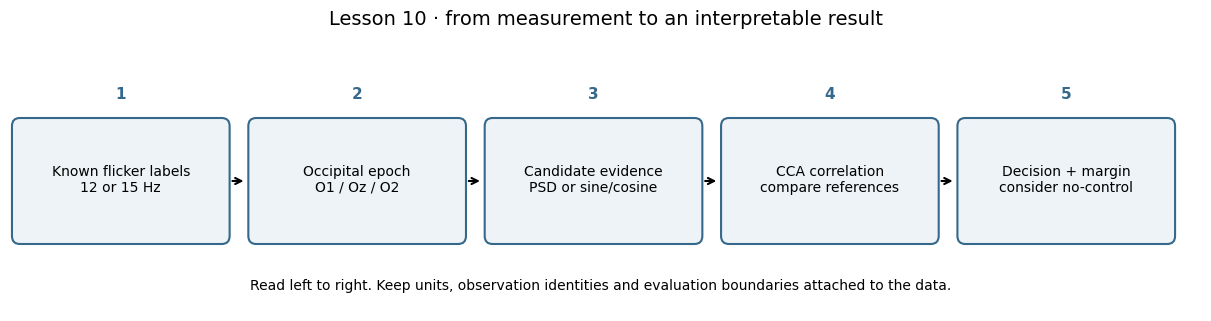

In [2]:
# Drawing code for the lesson map; no analysis data are transformed here.
from matplotlib.patches import FancyBboxPatch
map_steps=['Known flicker labels\n12 or 15 Hz', 'Occipital epoch\nO1 / Oz / O2', 'Candidate evidence\nPSD or sine/cosine', 'CCA correlation\ncompare references', 'Decision + margin\nconsider no-control']
fig,map_ax=plt.subplots(figsize=(12,3.1),constrained_layout=True)
map_ax.set(xlim=(-.1,12),ylim=(-.3,2.4));map_ax.axis('off')
for map_i,map_label in enumerate(map_steps):
    map_x=map_i*2.4
    map_ax.add_patch(FancyBboxPatch((map_x,.45),2.05,1.1,
        boxstyle='round,pad=0.08',facecolor='#edf3f7',edgecolor='#35688a',linewidth=1.5))
    map_ax.text(map_x+1.025,1.02,map_label,ha='center',va='center',fontsize=10)
    map_ax.text(map_x+1.025,1.83,str(map_i+1),ha='center',weight='bold',color='#35688a')
    if map_i<4:map_ax.annotate('',xy=(map_x+2.3,1),xytext=(map_x+2.13,1),arrowprops=dict(arrowstyle='->',lw=1.5))
map_ax.text(5.9,-.08,'Read left to right. Keep units, observation identities and evaluation boundaries attached to the data.',ha='center',fontsize=10)
map_ax.set_title('Lesson 10 · from measurement to an interpretable result',fontsize=14,pad=12)
plt.show()

**Read the map:** the arrows represent processing order, not permission to fit on all observations. When a stage learns parameters, keep evaluation data outside that fit. The map is also available as text: Known flicker labels: 12 or 15 Hz → Occipital epoch: O1 / Oz / O2 → Candidate evidence: PSD or sine/cosine → CCA correlation: compare references → Decision + margin: consider no-control.

## Symbols and a calculation by hand

$f$: candidate stimulation frequency; $H$: harmonics; $T$: duration; $a,b$: CCA projection weights.

### Derive the operation before calling the library

Use the identity $\sin(\omega t+\phi)=\cos\phi\sin\omega t+\sin\phi\cos\omega t$. Thus sine and cosine columns can represent any phase at the candidate frequency. With two harmonics, the reference has four columns and one row per time sample.

CCA maximizes the correlation between $Xa$ and $Y_fb$. Standard reference CCA chooses these weights separately for a trial without its class label; selecting channels or thresholds using labels still requires calibration. For a four-second window, nominal Fourier spacing is $1/T=0.25$ Hz. Padding the FFT to more bins interpolates that evidence; it does not create a longer observation.

### Your paper calculation

Rewrite one equation with the numerical example above. Name the input units and output units, and identify the axis being reduced or transformed.

**My calculation:** _write your intermediate steps here before continuing._

### The response follows a periodic stimulus

A steady-state visual evoked potential (SSVEP) is a response associated with periodic visual stimulation. Energy can appear at the stimulation frequency and its harmonics. An SSVEP interface assigns candidate frequencies to selectable targets, then compares the recorded response with those frequencies. This differs from P300 decoding, which detects a transient response to individual flashes, and from motor imagery, which uses changes in internally modulated rhythms.

The demonstration uses an existing MNE SSVEP recording. It does not present flashing stimuli. Target frequencies, event codes and channel names come from the dataset protocol; they must not be guessed from the strongest peak in the test data. Occipital channels are selected before evaluating labels.

### Duration sets a frequency scale

For an observation window of duration $T$, Fourier bins are spaced approximately $\Delta f=1/T$. A longer interval helps distinguish nearby periodic components but delays a decision. A taper reduces leakage from a finite window at the cost of broadening the spectral peak. Zero padding interpolates the spectrum without extending the observation duration.

A simple score compares target-bin power with nearby background power. The exact choice of neighboring bins matters: exclude the target and a small guard region, and avoid including another target or harmonic in the background estimate. A large ratio supports frequency-specific energy, but muscle activity, display artifacts and spontaneous alpha can also affect the spectrum.

### CCA combines channels and reference waveforms

For a candidate frequency $f$, construct reference columns

$$Y_f(t)=[\sin(2\pi ft),\cos(2\pi ft),\ldots,\sin(2\pi Hft),\cos(2\pi Hft)].$$

Sine and cosine allow an arbitrary phase at each harmonic. Canonical correlation analysis chooses linear combinations of EEG channels and reference columns that maximize their correlation:

$$\rho_f=\max_{a,b}\frac{a^T\Sigma_{XY_f}b}{\sqrt{a^T\Sigma_{XX}a}\sqrt{b^T\Sigma_{Y_fY_f}b}}.$$

The predicted target is the candidate with the largest correlation. Basic sinusoidal-reference CCA fits this association within each trial without using that trial's label. This is different from fitting a supervised model to all labeled trials. If channel selection, harmonic count or thresholds are chosen using accuracy, however, those choices require a separate calibration partition.

### Interpret success at the right scale

Two known targets and a small set of cued trials form a constrained classification problem. A practical interface must also handle no-control periods, gaze shifts, artifacts, uncertain evidence, latency and feedback. Reporting forced-choice accuracy alone hides false activations when the user intends nothing. A reject option can trade fewer wrong commands for longer or incomplete selections; select its threshold on calibration data and report both accepted fraction and accuracy among accepted decisions.

## Visual intuition · Match references at the candidate frequencies

**Try it:** Follow one cycle of each reference. What does adding cosine allow that sine alone does not?

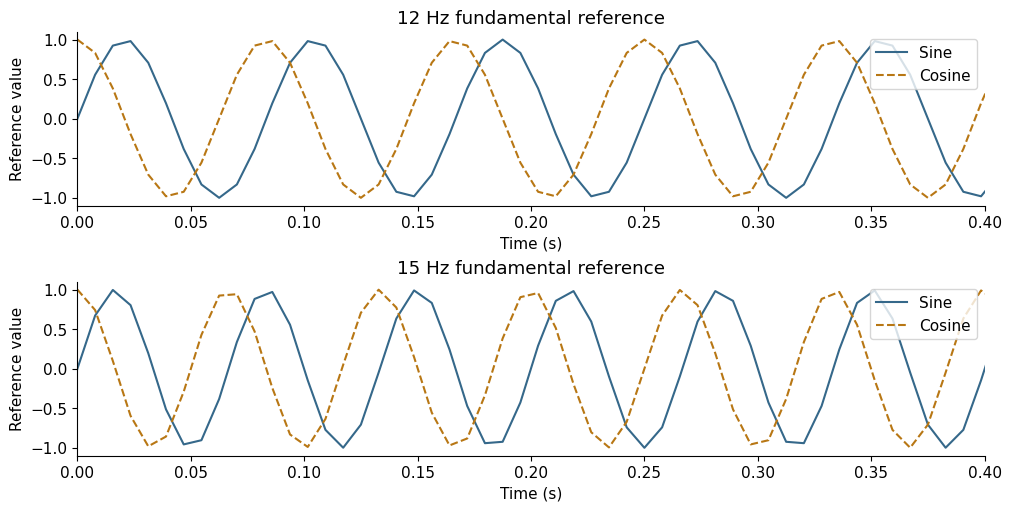

In [3]:
vis_t=np.arange(128)/128
fig,axes=plt.subplots(2,1,figsize=(10,5),constrained_layout=True)
for ax,frequency in zip(axes,[12,15]):
    ax.plot(vis_t,np.sin(2*np.pi*frequency*vis_t),label='Sine',color='#35688a')
    ax.plot(vis_t,np.cos(2*np.pi*frequency*vis_t),label='Cosine',color='#b87714',ls='--')
    ax.set(xlim=(0,.4),xlabel='Time (s)',ylabel='Reference value',title=f'{frequency} Hz fundamental reference')
    ax.legend(loc='upper right')
plt.show()

### Worked interpretation

The two basis functions are one quarter-cycle apart. Their weighted sum covers any phase at that frequency. Higher harmonics repeat this pair at integer multiples; the measured EEG need not look like a perfect sinusoid for CCA to detect association.

## Guided practice 1 · duration and frequency spacing

Calculate the bin spacing for short and long windows. Identify which durations provide a bin separation smaller than 1 Hz.

**Try it on paper:** predict the output’s shape, sign or approximate value. State which assumption makes your prediction valid.

**My prediction:** _write here._

**Hint:** trace one sample, one channel or one trial through the calculation before considering the full array.

### Worked solution · read one statement at a time

In [4]:
for duration in [.5,1,2,4]:
    print(f'{duration:g} s -> {1/duration:g} Hz bin spacing')

0.5 s -> 2 Hz bin spacing
1 s -> 1 Hz bin spacing
2 s -> 0.5 Hz bin spacing
4 s -> 0.25 Hz bin spacing


### Why this result makes sense

Bin spacing is a useful scale, not a guarantee that two noisy signals can be resolved perfectly.

**Check your understanding:** change one numerical parameter, predict the direction of change, and rerun. If the result disagrees, inspect units and axes before changing the method.

## Guided practice 2 · phase-invariant references

Represent a phase-shifted 12 Hz signal as a weighted sum of sine and cosine references.

**Try it on paper:** predict the output’s shape, sign or approximate value. State which assumption makes your prediction valid.

**My prediction:** _write here._

**Hint:** trace one sample, one channel or one trial through the calculation before considering the full array.

### Worked solution · read one statement at a time

In [5]:
demo_t=np.arange(256)/128
demo_Y=np.column_stack([np.sin(2*np.pi*12*demo_t),np.cos(2*np.pi*12*demo_t)])
demo_wave=np.sin(2*np.pi*12*demo_t+.7)
demo_coef=np.linalg.lstsq(demo_Y,demo_wave,rcond=None)[0]
print('Reference weights:',demo_coef)
assert np.allclose(demo_Y@demo_coef,demo_wave)

Reference weights: [0.76484219 0.64421769]


### Why this result makes sense

Using sine alone would unnecessarily assume a fixed phase. The two-column basis spans every phase at this frequency.

**Check your understanding:** change one numerical parameter, predict the direction of change, and rerun. If the result disagrees, inspect units and axes before changing the method.

## Guided practice 3 · harmonics are distinct features

Construct two harmonics and inspect their shapes. The samples are rows, matching scikit-learn’s observation convention.

**Try it on paper:** predict the output’s shape, sign or approximate value. State which assumption makes your prediction valid.

**My prediction:** _write here._

**Hint:** trace one sample, one channel or one trial through the calculation before considering the full array.

### Worked solution · read one statement at a time

In [6]:
demo_ref=np.column_stack([wave(2*np.pi*h*12*demo_t) for h in [1,2] for wave in [np.sin,np.cos]])
print('Reference shape:',demo_ref.shape)
print('Matrix rank:',np.linalg.matrix_rank(demo_ref))

Reference shape: (256, 4)
Matrix rank: 4


### Why this result makes sense

A harmonic reference uses multiples of the fundamental. Check that all requested harmonics remain below the sampling Nyquist frequency.

**Check your understanding:** change one numerical parameter, predict the direction of change, and rerun. If the result disagrees, inspect units and axes before changing the method.

## Guided practice 4 · accuracy after rejection

Apply two confidence thresholds to fixed illustrative decisions. Report the accepted fraction as well as accepted accuracy.

**Try it on paper:** predict the output’s shape, sign or approximate value. State which assumption makes your prediction valid.

**My prediction:** _write here._

**Hint:** trace one sample, one channel or one trial through the calculation before considering the full array.

### Worked solution · read one statement at a time

In [7]:
demo_conf=np.array([.2,.4,.6,.8,.9])
demo_correct=np.array([False,True,False,True,True])
for threshold in [.3,.7]:
    accepted=demo_conf>=threshold
    print('Threshold:',threshold,'Coverage:',accepted.mean(),'Accepted accuracy:',demo_correct[accepted].mean())

Threshold: 0.3 Coverage: 0.8 Accepted accuracy: 0.75
Threshold: 0.7 Coverage: 0.4 Accepted accuracy: 1.0


### Why this result makes sense

Higher accepted accuracy can result from refusing more trials. A usable interface needs both quantities and a policy for rejected selections.

**Check your understanding:** change one numerical parameter, predict the direction of change, and rerun. If the result disagrees, inspect units and axes before changing the method.

## Practice 1 · Reference builder

Implement harmonic_reference returning samples × (2 × harmonics), alternating sine and cosine.

**Try it:** complete the function below before reading its solution. The template deliberately returns None so that an unfinished attempt does not interrupt the rest of the lesson.

In [8]:
def harmonic_reference(times, frequency, harmonics=2):
    # TODO: one sine/cosine pair per harmonic.
    return None

### Hint

Use the equation above and keep the trial/channel axes intact unless the requested output removes them. Test the smallest example by hand first.

### Worked solution

Compare this implementation with your attempt. The next cell checks the reference answer on a concrete numerical case.

In [9]:
def harmonic_reference(times,frequency,harmonics=2):
    return np.column_stack([wave(2*np.pi*h*frequency*times) for h in range(1,harmonics+1) for wave in [np.sin,np.cos]])

In [10]:
answer=harmonic_reference(np.arange(128)/128,12,2)
if answer is not None:
    assert answer.shape==(128,4)
    assert np.allclose(answer[:,0],np.sin(2*np.pi*12*np.arange(128)/128))
    assert np.allclose(answer[0],[0,1,0,1]); print('Reference checks passed.')
else: print('Exercise pending: implement harmonic_reference.')

Reference checks passed.


## Apply the ideas to the complete pipeline

The next stages use the real recording or the explicitly labeled simulation described in the lesson. Keep preprocessing, feature extraction and evaluation decisions visible. Read each stage’s explanation before running its code.

### Method reference for the pipeline

SSVEP uses periodic visual stimulation to produce narrowband responses near the stimulus frequency and its harmonics. This differs from the transient ERP and self-paced motor-imagery paradigms. This recording is a frequency-tagging experiment, not a many-character online speller.

A local spectral SNR is $SNR(f)=P(f)/\mathrm{mean}_{g\in\mathcal N(f)}P(g)$, where neighboring bins exclude the center and guard bins. Guard bins avoid counting spectral leakage as background. A spectral maximum can be contaminated by spontaneous alpha, so occipital channels and harmonics help.

Canonical correlation chooses $a,b$ to maximize $\rho=\mathrm{corr}(X^Ta,Y_f^Tb)$, where $Y_f$ contains $\sin(2\pi hft)$ and $\cos(2\pi hft)$ for harmonics $h$. The frequency with the largest canonical correlation is selected. Fitting CCA to an individual test epoch and its known reference is part of this label-free decoder, not supervised training on its true label. Selecting channels, harmonics or window length using test accuracy would still leak.

## Load native MNE SSVEP data
The event mapping follows the dataset’s documented stimulus codes. Keep one decision per original trial.

Read the documented BrainVision recording, attach sensor geometry and map the two stimulus codes to their known frequencies. The epoch starts after stimulus onset to focus on a sustained response.

### Step 1.1 · trace the next operation

**1.** Store this intermediate result so the next operation can be traced and inspected.

**2.** Store this intermediate result so the next operation can be traced and inspected.

**3.** Read BrainVision metadata together with its linked signal/event files.

**4.** Attach sensor coordinates; this does not perform anatomical source localization.

**5.** Subtract the chosen EEG reference consistently across channels.

**6.** Apply the declared frequency filter; copy first when the original must be preserved.

**7.** Translate documented annotation descriptions into discrete event codes.

In [11]:
# Store this intermediate result so the next operation can be traced and inspected.
path = mne.datasets.ssvep.data_path(path=DATA_ROOT, update_path=False)
# Store this intermediate result so the next operation can be traced and inspected.
fname = path / 'sub-02' / 'ses-01' / 'eeg' / 'sub-02_ses-01_task-ssvep_eeg.vhdr'
# Read BrainVision metadata together with its linked signal/event files.
raw = mne.io.read_raw_brainvision(fname, preload=True, verbose=False)
# Attach sensor coordinates; this does not perform anatomical source localization.
raw.set_montage('easycap-M1')
# Subtract the chosen EEG reference consistently across channels.
raw.set_eeg_reference('average', projection=False)
# Apply the declared frequency filter; copy first when the original must be preserved.
raw.filter(1, 40)
# Translate documented annotation descriptions into discrete event codes.
events, _ = mne.events_from_annotations(raw, event_id={'Stimulus/S255': 12, 'Stimulus/S155': 15})

### Step 1.2 · trace the next operation

**1.** Create event-aligned trials with the stated interval, baseline and quality rules.

**2.** Expose the numerical array; EEG values are in volts and the final axis is time.

**3.** Keep one label or grouping identifier per trial in exactly the same order as the EEG array.

**4.** Display a bounded diagnostic; read the units, shape or partition rather than treating output as a success label.

In [12]:
# Create event-aligned trials with the stated interval, baseline and quality rules.
epochs = mne.Epochs(raw, events, {'12 Hz': 12, '15 Hz': 15}, 1, 5, baseline=None, picks=['O1', 'Oz', 'O2'], preload=True)
# Expose the numerical array; EEG values are in volts and the final axis is time.
X = epochs.get_data(copy=True)
# Keep one label or grouping identifier per trial in exactly the same order as the EEG array.
y = epochs.events[:, 2]
# Display a bounded diagnostic; read the units, shape or partition rather than treating output as a success label.
print('Original-trial decisions:', len(y), 'classes:', np.unique(y))

Original-trial decisions: 20 classes: [12 15]


### Inspect and interpret

Confirm the retained channels, frequencies and duration. Do not reinterpret a code using whichever peak is strongest in a particular test trial.

**Record in your notes:** the relevant shape/count or metric, the units where applicable, and one limitation of the inference.

## Practice 2 · Calculate the observed duration and frequency scale

**Try it:** Print sample count, sample rate, first-to-last timestamp span and nominal N/fs duration. Compare their inverse frequency scales.

**My reasoning / hand calculation:** _write here._

In [13]:
# Your attempt goes here. Work on copies and preserve the evaluation split.

### Hint

Inclusive endpoints make span and N/fs differ by one sample interval.

### Worked solution

Run the following calculation after attempting your own version.

In [14]:
lab_fs=epochs.info['sfreq'];lab_n=X.shape[-1]
print('Samples:',lab_n,'sample rate:',lab_fs)
print('Timestamp span:',epochs.times[-1]-epochs.times[0],'s')
print('DFT duration N/fs:',lab_n/lab_fs,'s; spacing fs/N:',lab_fs/lab_n,'Hz')

Samples: 4001 sample rate: 1000.0
Timestamp span: 4.0 s
DFT duration N/fs: 4.001 s; spacing fs/N: 0.24993751562109473 Hz


### Interpret and check

The requested interval is approximately four seconds; the exact array length includes its endpoint. Fourier-bin spacing follows fs/N. State the convention when comparing windows, especially in short segments.

## Measure spectral evidence
A four-second window has approximately 0.25 Hz native resolution.

Average spectra over the selected occipital channels, then compare candidate-frequency bins with nearby background bins. The guard region keeps target leakage out of the immediate noise estimate.

### Step 2.1 · trace the next operation

**1.** Estimate a density spectrum along time by averaging tapered segment spectra.

**2.** Name the intermediate representation so its dimensions can be checked before the next transformation.

**3.** Store this intermediate result so the next operation can be traced and inspected.

In [15]:
# Estimate a density spectrum along time by averaging tapered segment spectra.
f, P = signal.welch(X, fs=epochs.info['sfreq'], nperseg=X.shape[-1], axis=-1)
# Name the intermediate representation so its dimensions can be checked before the next transformation.
P = P.mean(axis=1)
# Store this intermediate result so the next operation can be traced and inspected.
snr = []

### Step 2.2 · trace the next operation

**1.** Repeat this operation over the explicitly listed groups while keeping their identities attached.

In [16]:
# Repeat this operation over the explicitly listed groups while keeping their identities attached.
for target in [12, 15]:
    idx = np.argmin(abs(f - target))
    neighbors = np.r_[idx - 5:idx - 1, idx + 2:idx + 6]
    snr.append(P[:, idx] / P[:, neighbors].mean(axis=1))

### Step 2.3 · trace the next operation

**1.** Make an explicit NumPy vector while preserving its current row order.

**2.** Store this intermediate result so the next operation can be traced and inspected.

**3.** Average class recalls so majority-class frequency does not dominate the score.

In [17]:
# Make an explicit NumPy vector while preserving its current row order.
snr = np.asarray(snr).T
# Store this intermediate result so the next operation can be traced and inspected.
pred = np.array([12, 15])[snr.argmax(1)]
# Average class recalls so majority-class frequency does not dominate the score.
print('Fixed SNR rule balanced accuracy:', balanced_accuracy_score(y, pred))

Fixed SNR rule balanced accuracy: 0.95


### Step 2.4 · trace the next operation

**1.** Create axes; plotting changes the display, not the analyzed data.

**2.** Plot each named condition on comparable axes without changing its observations.

**3.** Apply the stated operation to the current object; use the surrounding explanation to check its role.

**4.** Apply the stated operation to the current object; use the surrounding explanation to check its role.

**5.** Render the completed figure and inspect labels, units and the comparison.

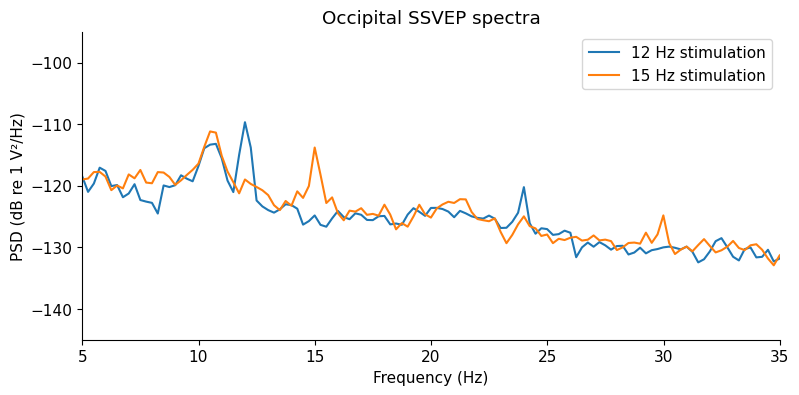

In [18]:
# Create axes; plotting changes the display, not the analyzed data.
fig, ax = plt.subplots()
# Plot each named condition on comparable axes without changing its observations.
for target in [12, 15]:
    ax.plot(f, 10 * np.log10(P[y == target].mean(0)), label=f'{target} Hz stimulation')
# Apply the stated operation to the current object; use the surrounding explanation to check its role.
ax.set(xlim=(5, 35), ylim=(-145, -95), xlabel='Frequency (Hz)', ylabel='PSD (dB re 1 V²/Hz)', title='Occipital SSVEP spectra')
# Apply the stated operation to the current object; use the surrounding explanation to check its role.
ax.legend()
# Render the completed figure and inspect labels, units and the comparison.
plt.show()

### Inspect and interpret

Locate both target frequencies and their possible harmonics. Examine score margins as well as forced-choice labels; a correct low-margin decision is still uncertain.

**Record in your notes:** the relevant shape/count or metric, the units where applicable, and one limitation of the inference.

## Practice 3 · Explain a spectral signal-to-noise ratio

**Try it:** Why leave guard bins around the target when estimating local background power?

**My reasoning / hand calculation:** _write here._

**My answer:** _write a short explanation before continuing._

### Hint

Finite-window leakage can spread a peak into neighboring bins.

### Worked solution

Immediate neighbors can contain leaked target energy. Including them as “noise” lowers the ratio for a reason caused by the estimator’s resolution rather than actual background alone. Guard size and neighboring target/harmonic locations must be considered together.

## Implement CCA classification
Use two harmonics and identical reference length for each trial.

For each candidate, construct sine/cosine harmonics over exactly the epoch’s time grid. CCA finds maximally associated EEG and reference combinations within that trial, then the strongest candidate wins.

### Step 3.1 · trace the next operation

**1.** Import the named tools used in this step.

In [19]:
# Import the named tools used in this step.
from sklearn.cross_decomposition import CCA

### Step 3.2 · trace the next operation

**1.** Define a reusable calculation; the body runs only when the function is called.

In [20]:
# Define a reusable calculation; the body runs only when the function is called.
def cca_score(epoch, frequency, sfreq, harmonics=2):
    # Build one time coordinate per sample at the supplied sampling rate.
    t = np.arange(epoch.shape[-1]) / sfreq
    # Create sine/cosine columns for each harmonic; samples form rows.
    reference = np.stack([fn(2 * np.pi * h * frequency * t) for h in range(1, harmonics + 1) for fn in (np.sin, np.cos)], axis=1)
    # Request the most strongly correlated EEG/reference pair of linear combinations.
    cca = CCA(n_components=1, max_iter=1000)
    # Estimate CCA projections using time samples in this trial, without its class label.
    u, v = cca.fit_transform(epoch.T, reference)
    # Return association strength for this candidate frequency; compare candidates afterward.
    return abs(np.corrcoef(u[:, 0], v[:, 0])[0, 1])

### Step 3.3 · trace the next operation

**1.** Store this intermediate result so the next operation can be traced and inspected.

**2.** Store this intermediate result so the next operation can be traced and inspected.

**3.** Average class recalls so majority-class frequency does not dominate the score.

**4.** Show which true classes are confused at the current decision rule.

**5.** Render the completed figure and inspect labels, units and the comparison.

Fixed CCA rule balanced accuracy: 1.0


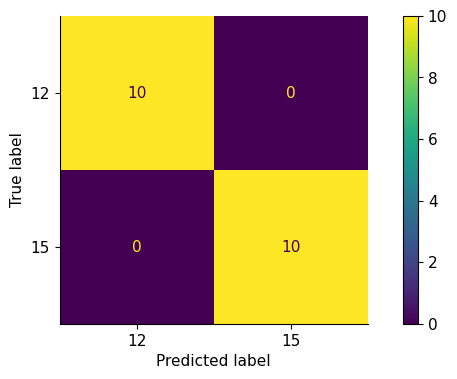

In [21]:
# Store this intermediate result so the next operation can be traced and inspected.
score = np.array([[cca_score(epoch, freq, epochs.info['sfreq']) for freq in [12, 15]] for epoch in X])
# Store this intermediate result so the next operation can be traced and inspected.
pred = np.array([12, 15])[score.argmax(1)]
# Average class recalls so majority-class frequency does not dominate the score.
print('Fixed CCA rule balanced accuracy:', balanced_accuracy_score(y, pred))
# Show which true classes are confused at the current decision rule.
ConfusionMatrixDisplay.from_predictions(y, pred)
# Render the completed figure and inspect labels, units and the comparison.
plt.show()

### Inspect and interpret

Compare spectral and CCA predictions on the same trial set. If both are perfect on this small benchmark, discuss why that does not establish performance during rest or among many targets.

**Record in your notes:** the relevant shape/count or metric, the units where applicable, and one limitation of the inference.

## Practice 4 · Inspect confidence margins without tuning a threshold

**Try it:** Compute the difference between the strongest and second strongest CCA score for each trial. Show the five smallest margins.

**My reasoning / hand calculation:** _write here._

In [22]:
# Your attempt goes here. Work on copies and preserve the evaluation split.

### Hint

Sort only for descriptive inspection; no threshold is selected here.

### Worked solution

Run the following calculation after attempting your own version.

In [23]:
lab_sorted=np.sort(score,axis=1)
lab_margin=lab_sorted[:,-1]-lab_sorted[:,-2]
lab_decision=np.array([12,15])[score.argmax(axis=1)]
lab_table=pd.DataFrame({'true_Hz':y,'predicted_Hz':lab_decision,'CCA_margin':lab_margin})
print(lab_table.sort_values('CCA_margin').head())

    true_Hz  predicted_Hz  CCA_margin
12       15            15    0.136061
11       15            15    0.136625
17       15            15    0.143408
15       15            15    0.147327
13       15            15    0.167215


### Interpret and check

A correct decision with a small margin can still be fragile. Margin-based rejection requires a calibration threshold and a report of both accepted fraction and accepted accuracy. These cued trials do not evaluate false activations during no-control periods.

## Practice 5 · Design a no-control test

**Try it:** What additional recordings are needed before turning every CCA argmax into a user command?

**My reasoning / hand calculation:** _write here._

**My answer:** _write a short explanation before continuing._

### Hint

Argmax always chooses something, even when all scores are weak.

### Worked solution

Include rest/no-intention periods, gaze transitions and representative artifacts with known timing. Evaluate false commands per unit time, missed intended commands, accepted coverage and latency. A reject policy must be calibrated separately. Two-class cued accuracy alone cannot establish this behavior.

## Practice 6 · explain the complete method

Without looking back, explain the measurement, transformation, feature or summary, and the evaluation boundary. Include one failure mode and one claim the result does not establish.

**My explanation:** _write here._

### Worked answer · compare your reasoning

SSVEP methods compare evidence at known candidate frequencies. Sine/cosine references handle phase, and harmonics enrich the model. Forced-choice cued accuracy does not establish safe or useful behavior during no-control periods.

## If your result is different

If candidate scores are similar, inspect trial duration, occipital channels, event mapping and reference frequencies. Perfect accuracy on a small cued set still needs no-control evaluation.

If a dataset download fails, read the error and retry when the public host is reachable; do not silently replace real data with simulated values. If a notebook cell refers to an undefined variable, restart the kernel and run the preceding cells in order. Numerical scores can vary slightly with library versions; record versions and compare the protocol before concluding that a method changed.

## Can you now do this independently?

- Explain each arrow in the lesson map and the units at its boundaries.
- Reproduce the hand calculation and point to its corresponding code.
- Interpret the figures without turning a descriptive pattern into an unsupported causal claim.
- Complete a practice task before reading its worked solution.
- State which choices were fixed and which were learned from calibration data.

If one item is unclear, return to the associated figure or practice section before the next lesson.

## Next steps and sources
[MNE SSVEP tutorial and provenance](https://mne.tools/stable/auto_tutorials/time-freq/50_ssvep.html) · [CCA API](https://scikit-learn.org/stable/modules/generated/sklearn.cross_decomposition.CCA.html).

Record package versions, subject/run IDs, preprocessing, split unit, random seed, and all exclusions with your results. Do not interpret a single participant as a population estimate.